In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np

# 1. Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print ([iris.target_names])
df['species'] = [iris.target_names[i] for i in iris.target]
df

[array(['setosa', 'versicolor', 'virginica'], dtype='<U10')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [9]:
sliced_df = pd.concat([df.head(5), df.tail(5)])
sliced_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [16]:
# 2. Select one flower species
flower_name = 'versicolor'
df_flower = df[df['species'] == flower_name]

# 3. Select two features
feature_x = 'sepal width (cm)'   # independent variable (X)
feature_y = 'petal length (cm)'   # dependent variable (Y)

X = df_flower[[feature_x]]  # X must be 2D
y = df_flower[feature_y]

In [17]:
# 4. Fit a linear regression model
model = LinearRegression()
model.fit(X, y)

# 5. Compute regression parameters
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# 6. Compute correlation coefficient (Pearson)
r, p_value = pearsonr(X.squeeze(), y)

# 7. Compute residuals (errors)
y_pred = model.predict(X)
residuals = y - y_pred

In [18]:
# 8. Print results
print(f"Linear regression for {flower_name}:")
print(f"Equation: {feature_y} = {intercept:.3f} + {slope:.3f} * {feature_x}")
print(f"Coefficient of determination (R²): {r2:.3f}")
print(f"Correlation coefficient (r): {r:.3f}")
print(f"Regression coefficient (slope): {slope:.3f}")

Linear regression for versicolor:
Equation: petal length (cm) = 1.935 + 0.839 * sepal width (cm)
Coefficient of determination (R²): 0.314
Correlation coefficient (r): 0.561
Regression coefficient (slope): 0.839


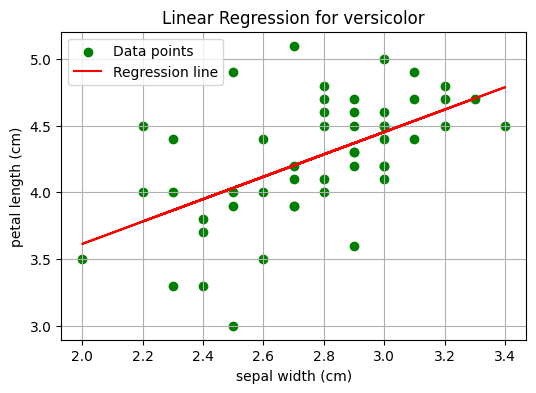

In [19]:
# 9. Scatter plot with regression line
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='green', label='Data points')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f'Linear Regression for {flower_name}')
plt.legend()
plt.grid(True)
plt.show()

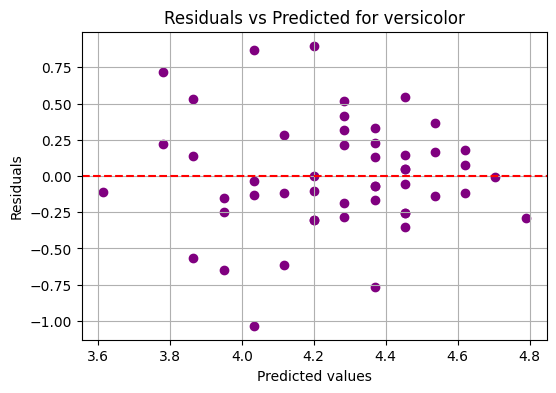

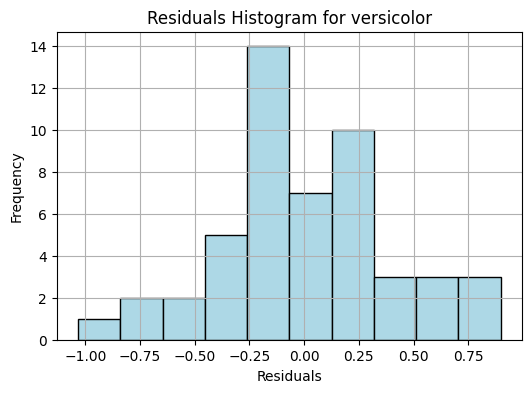

In [20]:
# 10. Residuals vs Predicted values
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')  # reference line at 0
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Predicted for {flower_name}')
plt.grid(True)
plt.show()

# 11. Histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=10, color='lightblue', edgecolor='black')
plt.title(f'Residuals Histogram for {flower_name}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()